# Notebook 02: Exploratory Data Analysis on Smoothed Technical Features

This notebook covers **Chapter 3 (Exploratory Data Analysis)** based on the output of Notebook 01.

Focus areas:
1. Statistical summary using full dataset structure (`pandas.info()` + descriptive tables).
2. Correlation analysis with next-day return label.
3. Trend and pattern discovery with rich visuals (histograms, box plots, time-series, scatter plots).

The notebook prioritizes interpretability and report-ready explanations.


In [142]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.4f}".format)


In [143]:
CONFIG_PATH = Path("../data/processed/modeling_config.json")
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True).sort_index()

feature_cols = cfg["feature_cols"]
target_col = cfg["target_col"]

print("Loaded target:", target_col)
print("Loaded training features:", feature_cols)

df.head()

Loaded target: target_close_1d
Loaded training features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14', 'volume']


,Adj Close,adj_close_smooth,target_ret_1d_pct,volume,rsi_14,macd_hist_12_26_9,adx_14,atr_14,obv,sma_10,ema_20,bb_bandwidth_20_2,target_close_1d
Date,,,,,,,,,,,,,
2016-05-31,22.7540,22.3406,-1.4020,167029009.6627,49.3275,0.3646,75.4397,2.3757,-1812086701.1363,21.6998,22.1960,7.1084,22.4350
2016-06-01,22.4350,22.3595,-0.7516,156961847.7302,49.8768,0.3581,70.5907,2.3729,-1655124853.4061,21.8123,22.2116,7.0941,22.2664
2016-06-02,22.2664,22.3409,0.2046,157722758.1842,49.3095,0.3424,66.2010,2.3658,-1812847611.5902,21.9166,22.2239,7.3274,22.3120
2016-06-03,22.3120,22.3351,0.7251,148982126.5473,49.1228,0.3216,62.1248,2.3596,-1961829738.1375,22.0171,22.2345,7.6846,22.4738
2016-06-06,22.4738,22.3628,0.4056,137819701.2379,50.0998,0.3003,57.8308,2.3665,-1824010036.8997,22.1130,22.2467,8.0985,22.5649


## 1) Statistical Summary (Full Dataset Structure)

The assignment guideline asks for statistical summarization and clear dataset inspection. We therefore include:
- `df.info()` to show data types, non-null counts, and memory usage.
- Descriptive statistics for all numeric fields.


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2480 entries, 2016-05-31 to 2026-04-10
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Adj Close          2480 non-null   float64
 1   adj_close_smooth   2480 non-null   float64
 2   target_ret_1d_pct  2480 non-null   float64
 3   volume             2480 non-null   float64
 4   rsi_14             2480 non-null   float64
 5   macd_hist_12_26_9  2480 non-null   float64
 6   adx_14             2480 non-null   float64
 7   atr_14             2480 non-null   float64
 8   obv                2480 non-null   float64
 9   sma_10             2480 non-null   float64
 10  ema_20             2480 non-null   float64
 11  bb_bandwidth_20_2  2480 non-null   float64
 12  target_close_1d    2480 non-null   float64
dtypes: float64(13)
memory usage: 271.2 KB


In [145]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Adj Close,2480.0000,121.9437,74.9885,20.9722,44.8737,128.1774,177.1805,285.9225
adj_close_smooth,2480.0000,121.5651,74.8121,21.5769,44.7021,127.5712,176.3958,279.2980
target_ret_1d_pct,2480.0000,0.1146,1.8238,-12.8647,-0.7103,0.1082,0.9849,15.3288
volume,2480.0000,97312146.0941,43935181.4853,33044503.5758,61961106.0332,91682444.5287,121039275.2051,325097084.3450
rsi_14,2480.0000,62.5784,27.5771,1.8274,38.6605,68.3688,87.2635,99.6856
macd_hist_12_26_9,2480.0000,-0.0022,0.6203,-2.4576,-0.2313,0.0260,0.2624,2.2288
adx_14,2480.0000,54.7920,19.5300,16.0100,39.1788,53.1612,68.4547,95.6932
atr_14,2480.0000,3.9322,1.1188,2.3011,3.0002,3.7518,4.7854,9.0308
obv,2480.0000,31134375302.6331,15000125499.1265,-3237381335.5418,16886870155.0663,38509883124.3041,43962300206.7163,49859292904.7781
sma_10,2480.0000,121.1425,74.6929,21.6786,44.5457,127.3446,176.4426,278.4994


## 2) Feature Distribution Analysis (Histogram + Box Plot)

Each selected feature is visualized using:
- histogram (shape/distribution), and
- box plot (spread/outliers).

This helps assess scaling, heavy tails, and regime behavior before modeling.


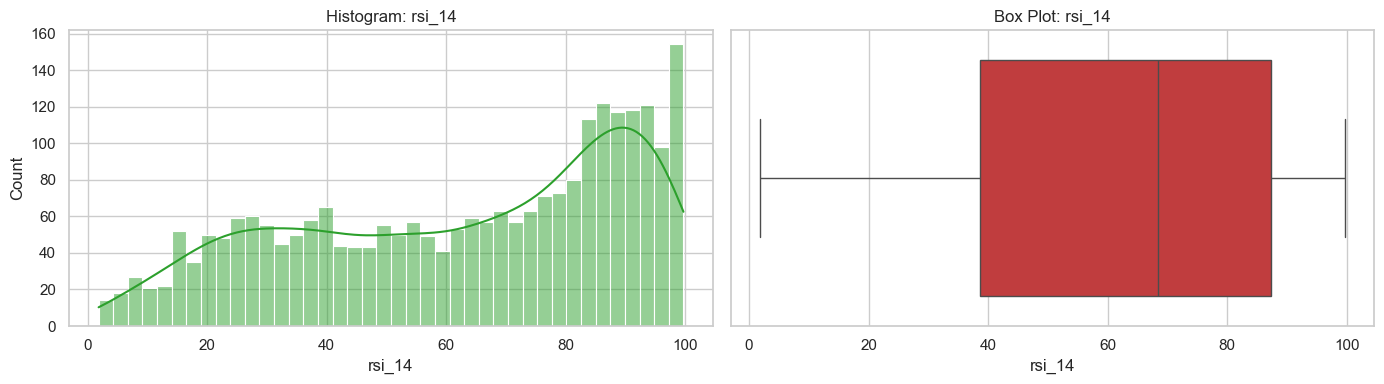

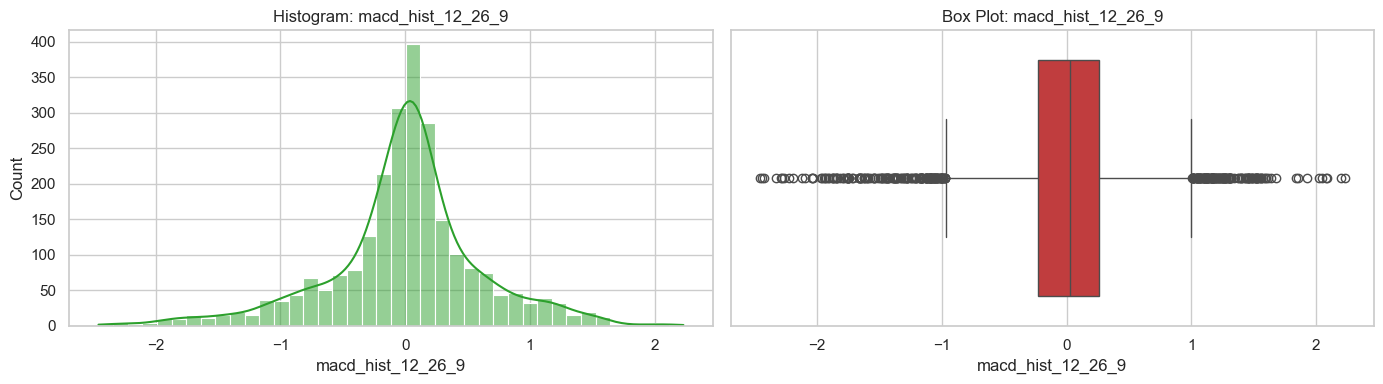

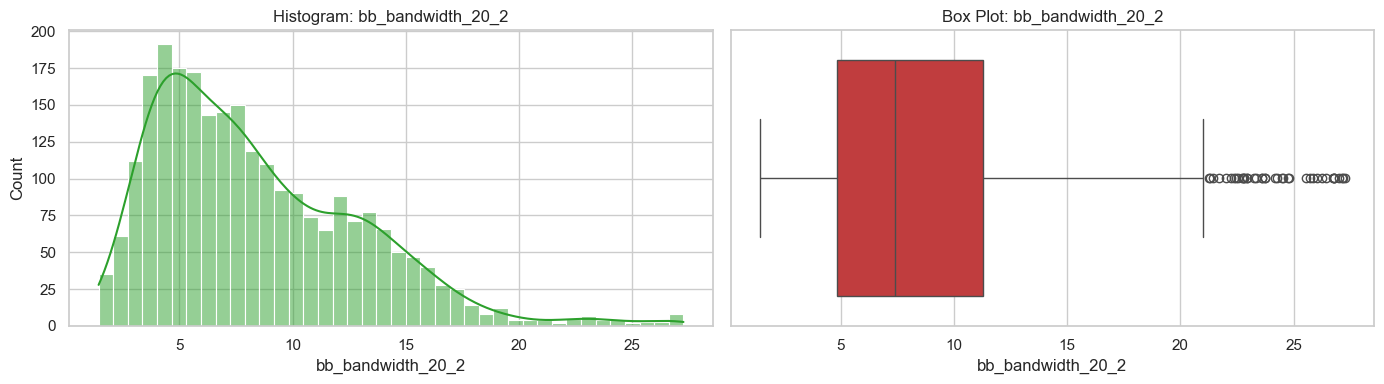

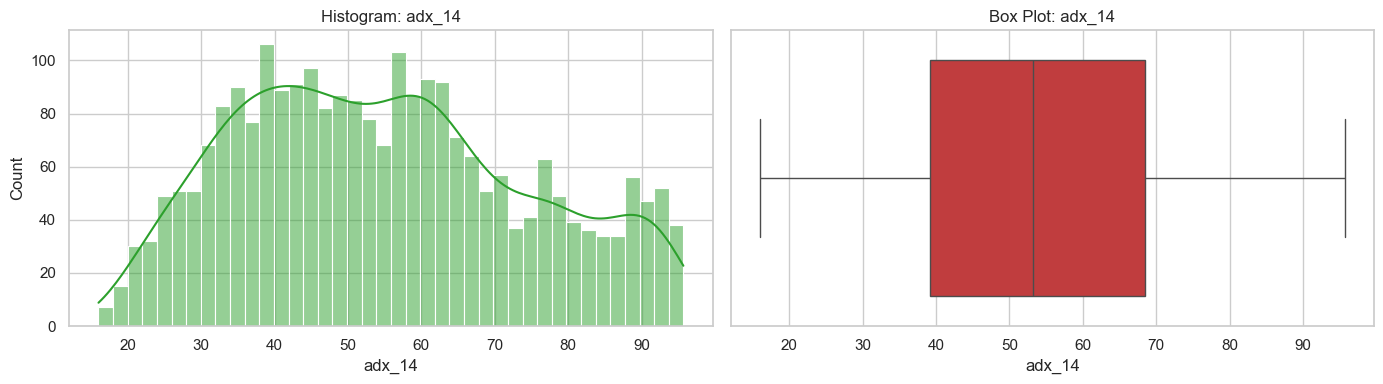

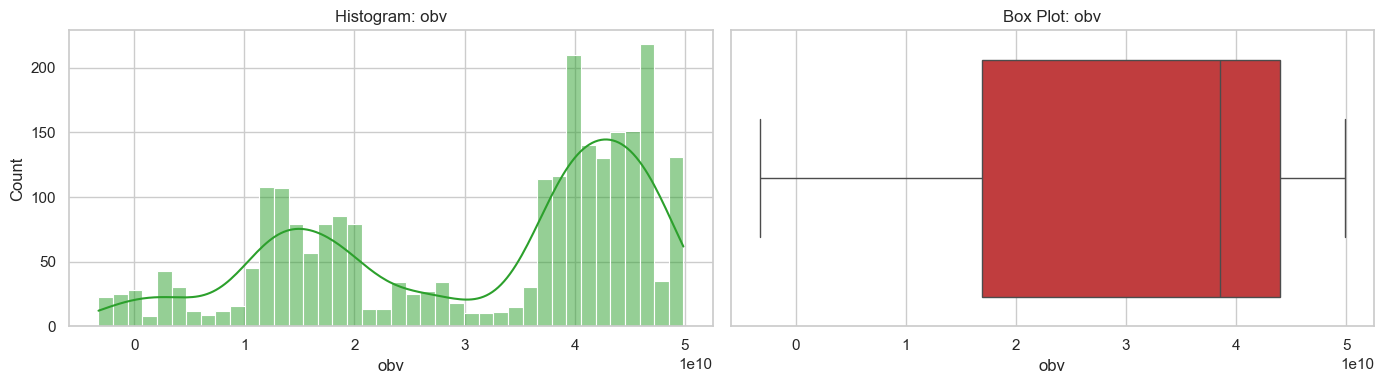

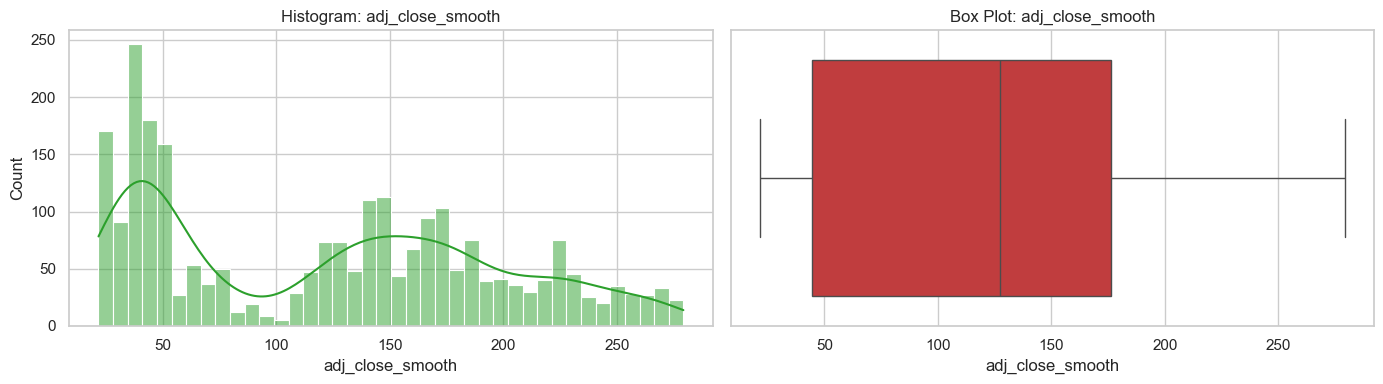

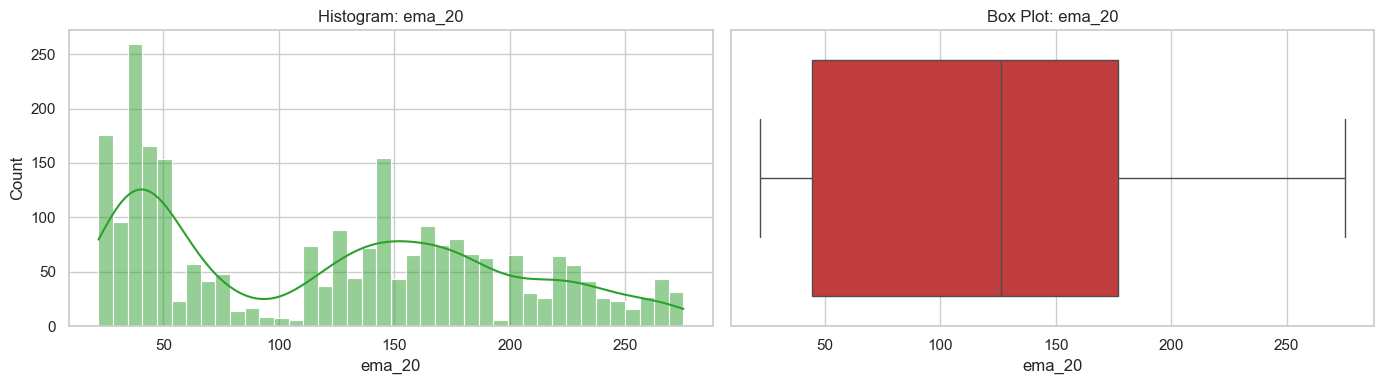

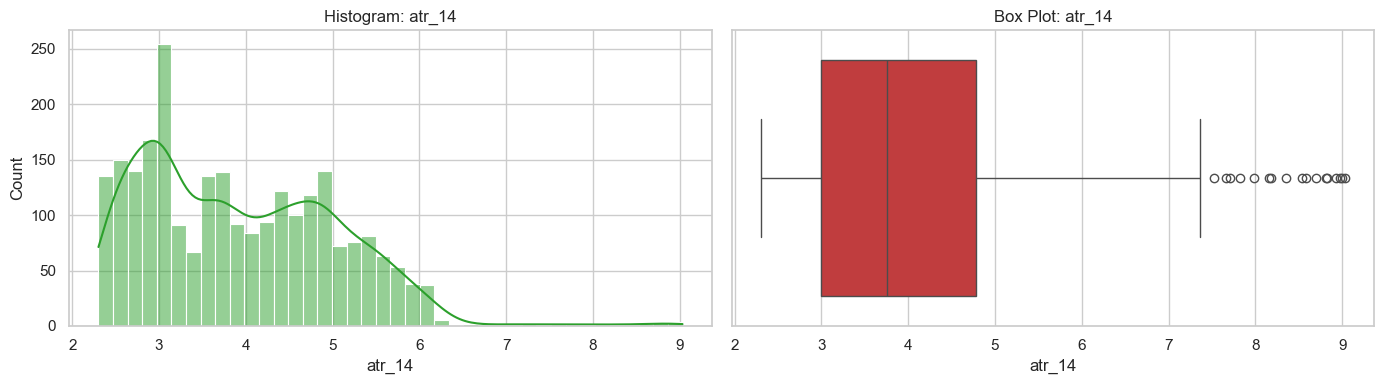

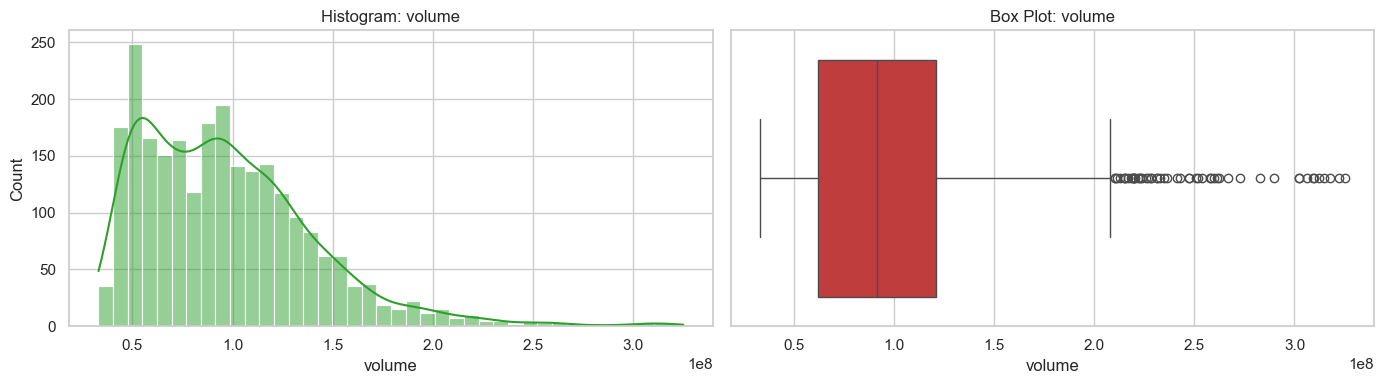

In [146]:
for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[col], bins=40, kde=True, ax=axes[0], color="#2ca02c")
    axes[0].set_title(f"Histogram: {col}")
    axes[0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[1], color="#d62728")
    axes[1].set_title(f"Box Plot: {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

### Insight Justification: Feature Distributions

Feature-wise histograms and box plots reveal each indicator's shape, spread, and extreme behavior.
This supports interpretation of market regimes and highlights whether transformation/scaling may be needed in later modeling chapters.


## 4) Correlation Analysis with Target


A feature-feature heatmap is also included to inspect remaining multicollinearity.


In [147]:
pearson = df[feature_cols + [target_col]].corr(method="pearson")
pearson[target_col].drop(target_col).sort_values(ascending=False)

adj_close_smooth     0.9986
ema_20               0.9960
obv                  0.9340
atr_14               0.6821
macd_hist_12_26_9   -0.0161
bb_bandwidth_20_2   -0.0576
rsi_14              -0.0934
adx_14              -0.1828
volume              -0.6866
Name: target_close_1d, dtype: float64

### Insight Justification: Feature-Target Correlation

Pearson and Spearman values quantify linear and monotonic relationships with the next-day return label.
Even modest correlations are informative in finance, where signal-to-noise is usually low.


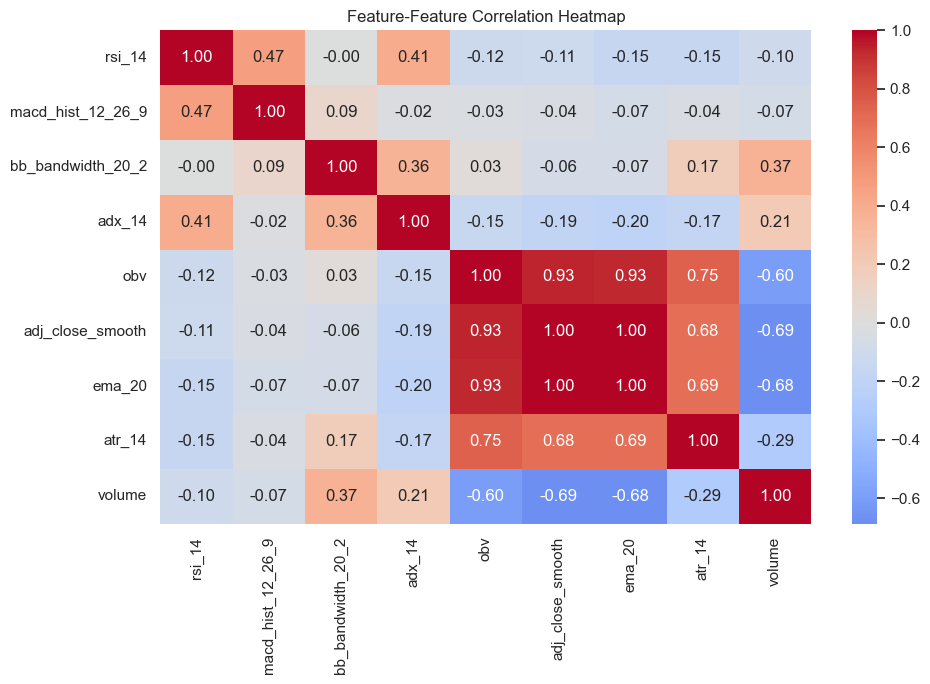

In [148]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature-Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Insight Justification: Multicollinearity Check

The heatmap is used to identify redundant indicator pairs.
This helps keep later regression models stable and interpretable by avoiding highly overlapping predictors.


## 5) Trend and Pattern Discovery

Visual trend analysis improves the quality of interpretation in the report. We examine:


In [ ]:
# used to selectively show relevant recent data in EDA plots 
# to not overwhelm the visualizations with too much data

def trim(df, year=3):
    df.index = pd.to_datetime(df.index)
    end_date = df.index.max()
    start_date = end_date - pd.DateOffset(years=year)

    return df.loc[df.index >= start_date].copy()

### ADX Trend-Strength Visualization and Regime Summary

This section uses ADX(14) to interpret **trend strength** (non-directional) by shading price periods for weak vs extremely strong regimes, plotting ADX against key thresholds, and summarizing next-day return statistics by ADX strength buckets to evaluate how trend strength relates to subsequent returns.

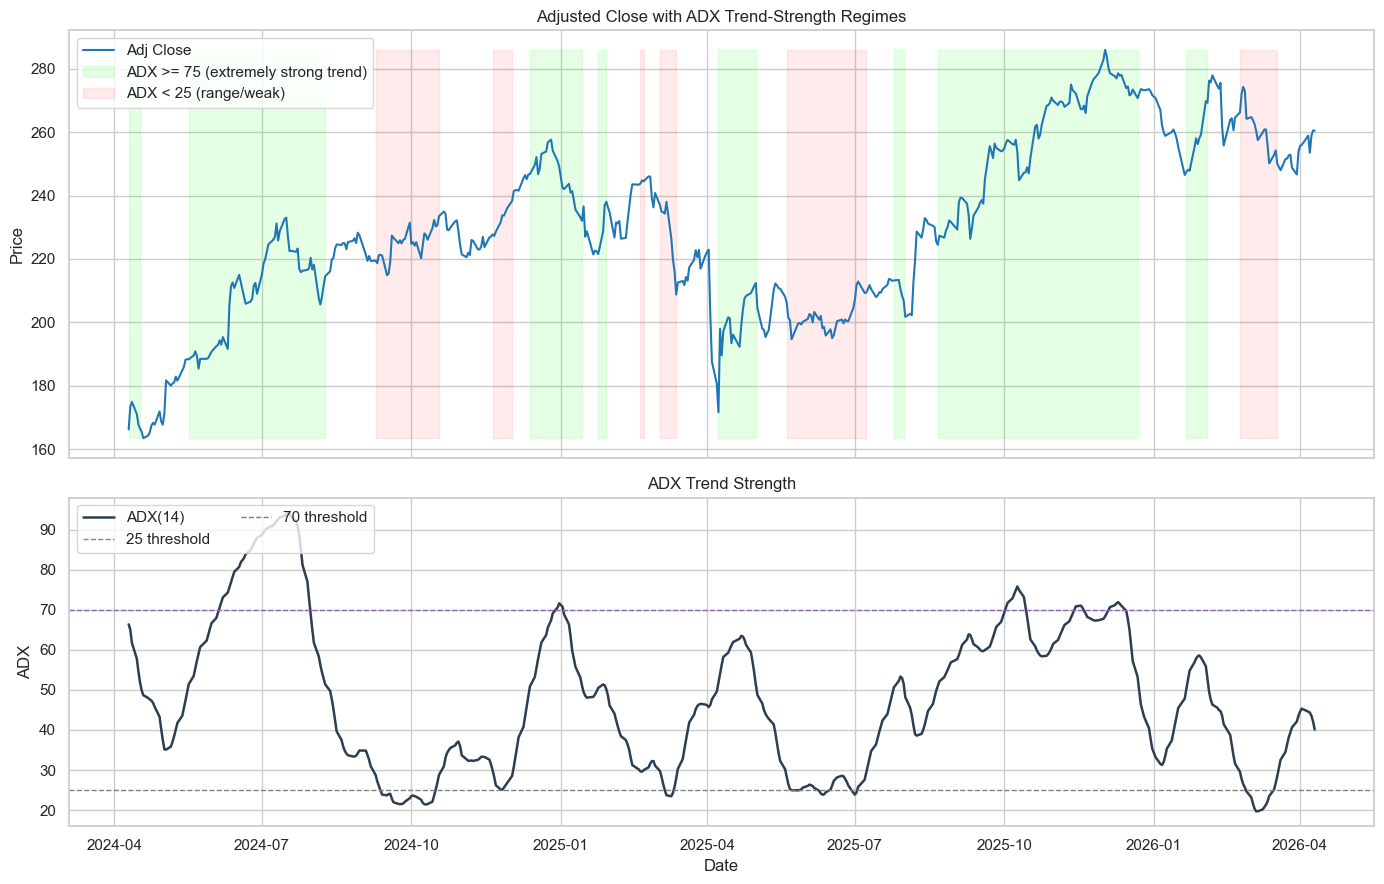

,observations,mean_return_pct,median_return_pct,return_std_pct
adx_regime,,,,
<25 weak,49,-0.0947,0.1049,1.6127
25-50 strong,247,-0.0196,0.0596,1.6734
50-75 very strong,172,0.3439,0.2946,2.0049
>75 extremely strong,34,0.0707,0.2849,1.6369


In [150]:
# ADX visualization (Investopedia-style strength interpretation)
# ADX is non-directional: it measures trend strength, not up/down direction.
# Common interpretation: <20 weak/range, >25 stronger trend, >50 very strong trend.
df_curr = trim(df, 2)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})

# Panel 1: Price with ADX regime shading
axes[0].plot(df_curr.index, df_curr["Adj Close"], color="#1f77b4", linewidth=1.5, label="Adj Close")

strong = df_curr["adx_14"] >= 50
weak = df_curr["adx_14"] < 30

axes[0].fill_between(df_curr.index, df_curr["Adj Close"].min(), df_curr["Adj Close"].max(), where=strong, color="#00ff00", alpha=0.10, label="ADX >= 75 (extremely strong trend)")
axes[0].fill_between(df_curr.index, df_curr["Adj Close"].min(), df_curr["Adj Close"].max(), where=weak, color="#ff0000", alpha=0.08, label="ADX < 25 (range/weak)")
axes[0].set_title("Adjusted Close with ADX Trend-Strength Regimes")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

# Panel 2: ADX with thresholds
axes[1].plot(df_curr.index, df_curr["adx_14"], color="#2c3e50", linewidth=1.8, label="ADX(14)")
axes[1].axhline(25, linestyle="--", color="gray", linewidth=1, label="25 threshold")
axes[1].axhline(70, linestyle="--", color="#9467bd", linewidth=1, label="70 threshold")
axes[1].set_title("ADX Trend Strength")
axes[1].set_ylabel("ADX")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

# Report-friendly ADX regime summary table
regime = pd.cut(df_curr["adx_14"], bins=[-np.inf, 25, 50, 75, np.inf], labels=["<25 weak", "25-50 strong", "50-75 very strong", ">75 extremely strong"])
regime_summary = (
    df_curr.assign(adx_regime=regime)
      .groupby("adx_regime", observed=False)
      .agg(
          observations=("target_ret_1d_pct", "size"),
          mean_return_pct=("target_ret_1d_pct", "mean"),
          median_return_pct=("target_ret_1d_pct", "median"),
          return_std_pct=("target_ret_1d_pct", "std"),
      )
      .round(4)
)
regime_summary

### RSI vs Price (Oversold/Overbought) Insight

This section plots Apple’s adjusted close alongside RSI(14), highlighting oversold windows (RSI < 20) and marking the overbought threshold (RSI > 70) to visualize momentum extremes.

#### Insights

After RSI enters the oversold zone (e.g., RSI < 20), Apple’s price often rebounds in the following periods, consistent with short-term mean reversion after sharp selloffs.

Plus, Apple spends more time in the overbought region (RSI > 70) and tends to remain there longer than it does in oversold conditions, suggesting sustained bullish momentum and overall stock strength.

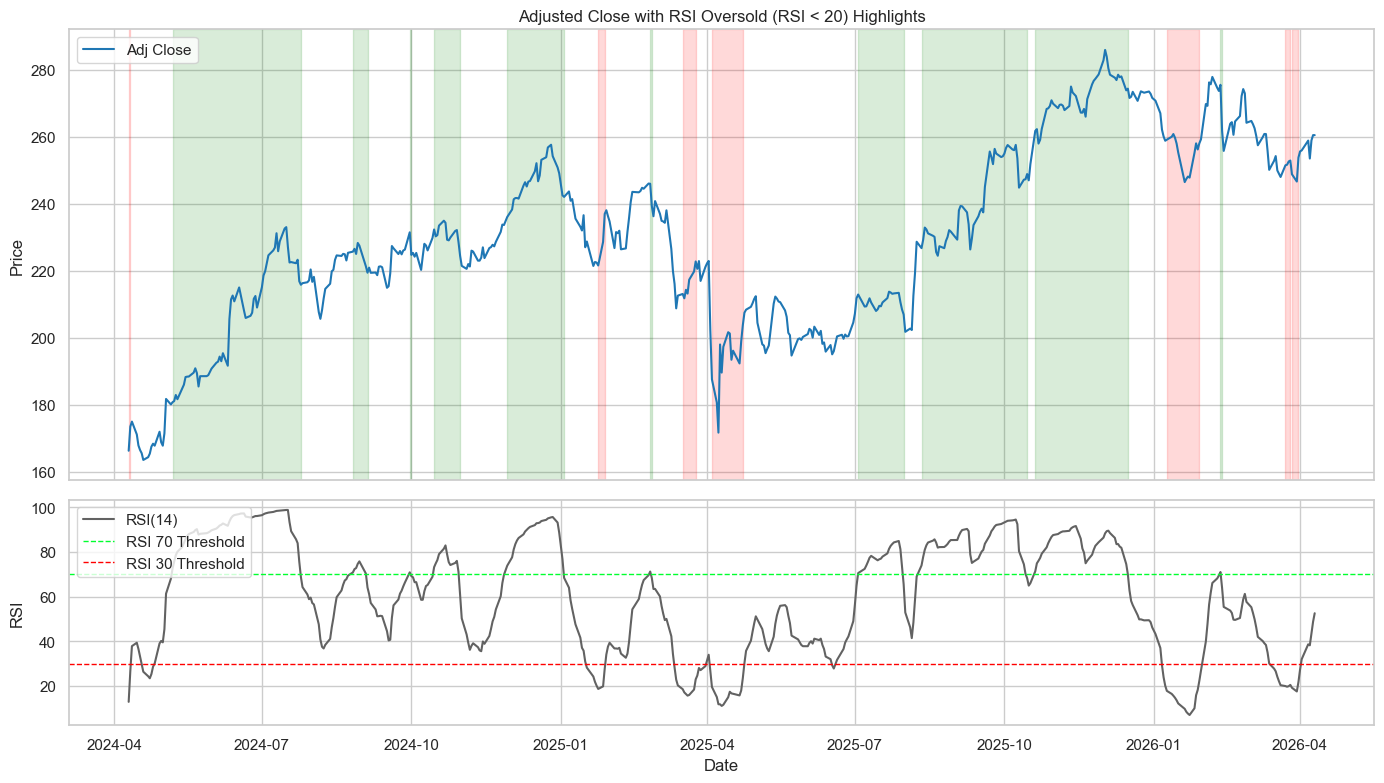

In [155]:
# RSI vs price with overbought highlight (RSI > 70)
df_curr = trim(df, 2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(df_curr.index, df_curr["Adj Close"], color="#1f77b4", label="Adj Close")
axes[0].set_title("Adjusted Close with RSI Oversold (RSI < 20) Highlights")
axes[0].set_ylabel("Price")

rsi_oversold = df_curr["rsi_14"] < 20
rsi_overbought = df_curr["rsi_14"] > 70
if rsi_oversold.any():
    start = None
    for idx, flag in rsi_oversold.items():
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            axes[0].axvspan(start, idx, color="red", alpha=0.15)
            start = None
    if start is not None:
        axes[0].axvspan(start, df_curr.index[-1], color="red", alpha=0.15)

if rsi_overbought.any():
    start = None
    for idx, flag in rsi_overbought.items():
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            axes[0].axvspan(start, idx, color="green", alpha=0.15)
            start = None
    if start is not None:
        axes[0].axvspan(start, df_curr.index[-1], color="green", alpha=0.15)

axes[1].plot(df_curr.index, df_curr["rsi_14"], color="#626262", label="RSI(14)")
axes[1].axhline(70, linestyle="--", color="#00FF2F", linewidth=1, label="RSI 70 Threshold")
axes[1].axhline(30, linestyle="--", color="#ff0000", linewidth=1, label="RSI 30 Threshold")
axes[1].set_ylabel("RSI")
axes[1].set_xlabel("Date")

axes[0].legend(loc="upper left")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

### MACD Histogram vs Next-Day Return (Quintile Analysis)

This section bins the MACD histogram into quintiles (from low to high) and uses a boxplot to compare the distribution of next-day returns across bins. This helps to assess whether MACD momentum is associated with stronger or weaker next-day performance.

`Q1` to `Q5` are **quintile bins** of your `MACD histogram` values:

- `Q1` = lowest 20% of MACD histogram values (most negative/weakest momentum)
- `Q5` = highest 20% (most positive/strongest momentum)


**Insights**

Across Q1 to Q5, the main differences show up in the tails: Q1 has an unusually large positive outlier (around +15%), while Q4 shows some of the most extreme negative outliers (around -9%). Plus, even the mean return of Q5 is notably negative, despite Q5 representing the most positive momentum. 

Because the MACD histogram is an “acceleration” measure, a high value can reflect strengthening momentum, but it can also appear after an extended run when price is already very high, and a reversal in stock price is to be expected. The opposite is true too, for overly negative values.

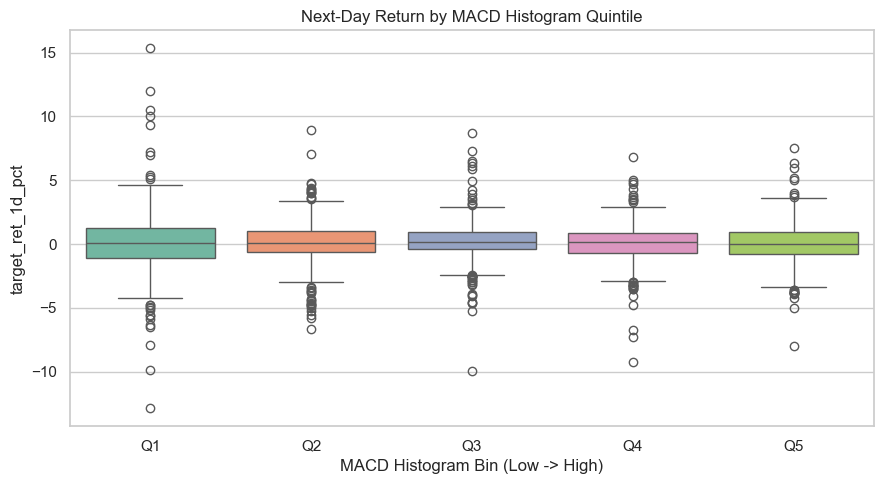

,observations,mean_return_pct,min_return_pct,max_return_pct
macd_bin,,,,
Q1,496,0.0606,-12.8647,15.3288
Q2,496,0.0967,-6.6331,8.8975
Q3,496,0.2355,-9.9607,8.7237
Q4,496,0.1202,-9.2456,6.8334
Q5,496,0.0601,-8.0061,7.5552


In [152]:
# MACD relationship with next-day return (quintile boxplot only)

macd_bins = pd.qcut(df["macd_hist_12_26_9"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")

plot_df = df[["target_ret_1d_pct"]].copy()
plot_df["macd_bin"] = macd_bins

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="macd_bin", y="target_ret_1d_pct", hue="macd_bin", palette="Set2", legend=False)
plt.title("Next-Day Return by MACD Histogram Quintile")
plt.xlabel("MACD Histogram Bin (Low -> High)")
plt.ylabel("target_ret_1d_pct")
plt.tight_layout()
plt.show()

# Robust labels in case qcut drops duplicate edges
q_labels = [f"Q{i+1}" for i in range(macd_bins.cat.categories.size)]
macd_bin = macd_bins.cat.rename_categories(q_labels)

macd_summary = (
    df.assign(macd_bin=macd_bin)
      .groupby("macd_bin", observed=False)
      .agg(
          observations=("target_ret_1d_pct", "size"),
          mean_return_pct=("target_ret_1d_pct", "mean"),
          min_return_pct=("target_ret_1d_pct", "min"),
          max_return_pct=("target_ret_1d_pct", "max"),
      )
      .round(4)
)

macd_summary


### Bollinger Bands and Bandwidth (Volatility Visualization)

This section plots Bollinger Bands (20-day mean with ±2 standard deviations) against the adjusted close to show when price moves toward statistical extremes, and it tracks Bollinger Bandwidth over time to highlight periods of expanding vs contracting volatility (potential breakouts vs consolidations).

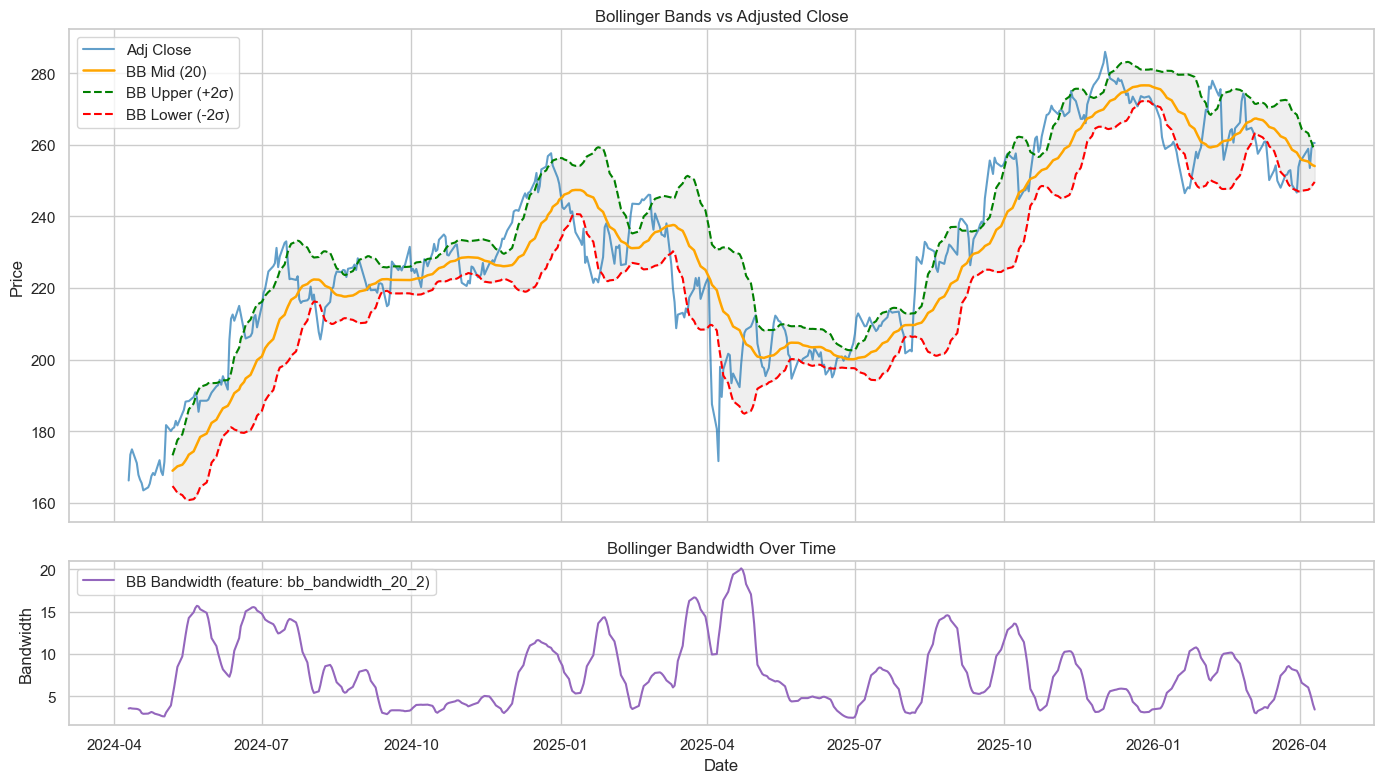

In [153]:
# Bollinger Bands (20,2) against adjusted close + Bandwidth
df_curr = trim(df, 2)

rolling_mid = df_curr["adj_close_smooth"].rolling(window=20).mean()
rolling_std = df_curr["adj_close_smooth"].rolling(window=20).std()
bb_upper = rolling_mid + 2 * rolling_std
bb_lower = rolling_mid - 2 * rolling_std
bb_width = bb_upper - bb_lower

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Price + bands
ax = axes[0]
ax.plot(df_curr.index, df_curr["Adj Close"], label="Adj Close", color="#1f77b4", alpha=0.7)
ax.plot(df_curr.index, rolling_mid, label="BB Mid (20)", color="orange", linewidth=1.8)
ax.plot(df_curr.index, bb_upper, label="BB Upper (+2σ)", color="green", linestyle="--")
ax.plot(df_curr.index, bb_lower, label="BB Lower (-2σ)", color="red", linestyle="--")
ax.fill_between(df_curr.index, bb_lower, bb_upper, color="gray", alpha=0.12)
ax.set_title("Bollinger Bands vs Adjusted Close")
ax.set_ylabel("Price")
ax.legend(loc="upper left")

# Bandwidth
ax2 = axes[1]
if "bb_bandwidth_20_2" in df_curr.columns:
    bandwidth = df_curr["bb_bandwidth_20_2"]
    ax2.plot(df_curr.index, bandwidth, label="BB Bandwidth (feature: bb_bandwidth_20_2)", color="#9467bd")
else:
    bandwidth = (bb_width / rolling_mid) * 100
    ax2.plot(df_curr.index, bandwidth, label="BB Bandwidth (%): (Upper-Lower)/Mid * 100", color="#9467bd")

ax2.set_title("Bollinger Bandwidth Over Time")
ax2.set_xlabel("Date")
ax2.set_ylabel("Bandwidth")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 7) EDA Interpretation Notes for Report Writing

Use this section to summarize Chapter 3 insights in your report:

1. Statistical profile:
   - Describe central tendency and dispersion of `target_ret_1d_pct`.
   - Mention any visible skewness and outliers.

2. Feature behavior:
   - Highlight which indicators are stable vs highly volatile.
   - Note any non-Gaussian feature distributions.

3. Correlation findings:
   - Report strongest positive/negative feature-target relationships.
   - Discuss whether correlations are weak/moderate/strong and implications for linear regression.

4. Regime insights:
   - Explain how target distribution differs between trending and ranging periods (ADX regimes).

5. Model implication:
   - If relationships appear weakly linear or regime-dependent, note this as motivation for comparing additional models in later chapters.
